In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence
from utils.helpers import *
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

device = find_backend()

Currently using:  mps


In [3]:
import pandas as pd

splits = {'train': 'Personality Datasets - Reddit/train_set.csv', 'validation': 'Personality Datasets - Reddit/val_set.csv', 'test': 'Personality Datasets - Reddit/eval_set.csv'}
train = pd.read_csv("hf://datasets/Fatima0923/Automated-Personality-Prediction/" + splits["train"])
test = pd.read_csv("hf://datasets/Fatima0923/Automated-Personality-Prediction/" + splits["test"])
validation = pd.read_csv("hf://datasets/Fatima0923/Automated-Personality-Prediction/" + splits["validation"])

In [4]:
train.sample(5)

,text,agreeableness,openness,conscientiousness,extraversion,neuroticism
903,yes they do neuroscientists have been working ...,12.0,84.0,7.0,53.0,54.0
11499,theres nothing to rebut â proving what let me ...,38.0,86.0,10.0,3.0,69.0
645,i would love a link as well thank you,57.0,80.0,86.0,79.0,55.0
5776,from my experience i tend to be interested and...,98.0,40.0,1.0,1.0,99.0
8345,okay no worries thank you anyways,86.0,45.0,25.0,59.0,67.0


In [1]:
from transformers import AutoTokenizer, DistilBertModel
tokenizer = AutoTokenizer.from_pretrained("t5-small")
# teacher_model = DistilBertModel.from_pretrained("distilbert-base-uncased")

ValueError: Unrecognized model identifier in t5-small. Should contains one of 'bert', 'openai-gpt', 'gpt2', 'transfo-xl', 'xlnet', 'xlm', 'roberta', 'ctrl'

In [6]:
train["tokenized"] = tokenize_column(train["text"], tokenizer)
train["len_seq"] = train['tokenized'].apply(lambda x:len(x))
train["len_seq"].describe(percentiles=[0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,0.95])

count    16047.000000
mean        55.502399
std         93.263083
min          5.000000
10%          8.000000
20%         12.000000
30%         16.000000
40%         21.000000
50%         27.000000
60%         36.000000
70%         49.000000
80%         72.000000
90%        124.000000
95%        194.000000
max       2389.000000
Name: len_seq, dtype: float64

<Axes: >

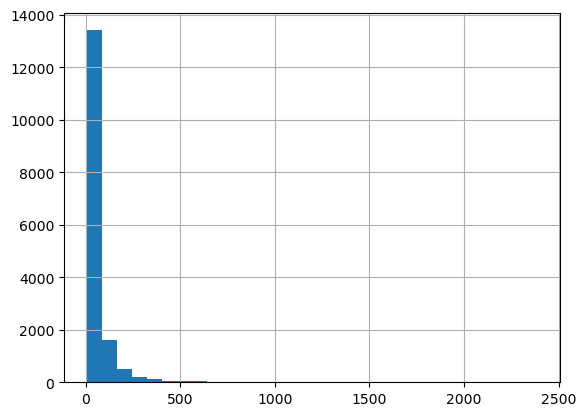

In [7]:
train["len_seq"].hist(bins = 30)

#### if we keep max_length around 128 for prototyping we should be able to cover 90% of the data

In [8]:
from models import encoder_decoder, decoder_only

model_type = "encoder_decoder" 
# model_type = "decoder_only"

vocab_size = tokenizer.vocab_size
hidden_dim=128
num_heads=2
dim_feedforward=2048
num_layers_enc=2
num_layers_dec=2
dropout=0.1
max_length=128
p_tags=5
ignore_index = -1

if model_type == "encoder_decoder":
    model =  encoder_decoder.EncoderDecoder(vocab_size,device, hidden_dim, num_heads, dim_feedforward, num_layers_enc, num_layers_dec, dropout,
                                            max_length, p_tags, ignore_index)

model = model.to(device)

In [9]:
input_test = torch.tensor(tokenizer.encode("This is an example")).unsqueeze(0).to(device)
output_test = torch.tensor(tokenizer.encode("This is output example")).unsqueeze(0).to(device)
personality_test = torch.rand(1,5).to(device)

input_test, output_test, personality_test

(tensor([[2023, 2003, 2019, 2742]], device='mps:0'),
 tensor([[2023, 2003, 6434, 2742]], device='mps:0'),
 tensor([[0.5245, 0.9158, 0.6466, 0.2648, 0.6718]], device='mps:0'))

In [44]:
model(input_test, output_test, personality_test)

/opt/homebrew/Caskroom/miniforge/base/envs/personality_llm/lib/python3.12/site-packages/torch/nn/functional.py:5962: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


tensor([[[ 0.3838, -0.8160,  0.7298,  ..., -0.1770,  0.1024,  0.4150],
         [ 0.4897,  0.6581,  0.8738,  ...,  0.4251,  0.2263,  0.0521],
         [ 0.4618, -0.1203,  0.6499,  ...,  0.3767,  0.1755, -0.3224],
         [ 0.0421,  0.5217,  1.2867,  ..., -0.0753, -0.4958,  0.1014]]],
       device='mps:0', grad_fn=<LinearBackward0>)

In [45]:
tokenizer.max_len = max_length

In [48]:
train = encode_text(train, tokenizer, max_length)
test = encode_text(test, tokenizer, max_length)
validation = encode_text(test, tokenizer, max_length)

,text,agreeableness,openness,conscientiousness,extraversion,neuroticism,tokenized,len_seq,encoded
6332,thanks for the additional shapeshifting powers,2.0,92.0,31.0,60.0,53.0,"[thanks, for, the, additional, shapes, ##hi, #...",8,"[4283, 2005, 1996, 3176, 10466, 4048, 26169, 4..."
12652,article yes thanking god after a tragedy is ve...,3.0,90.0,52.0,9.0,49.0,"[article, yes, thanking, god, after, a, traged...",38,"[3720, 2748, 28638, 2643, 2044, 1037, 10576, 2..."


In [10]:
tokenizer = AutoTokenizer.from_pretrained('t5-small')

ValueError: Unrecognized model identifier in t5-small. Should contains one of 'bert', 'openai-gpt', 'gpt2', 'transfo-xl', 'xlnet', 'xlm', 'roberta', 'ctrl'

TypeError: 'DistilBertTokenizer' object is not callable